In [1]:
import os
import numpy as np  
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from stargazer.stargazer import Stargazer

In [2]:

df_path = os.path.join("..", "data", "combined.csv")   # ../data/combined.csv from src/
assert os.path.exists(df_path), f"File not found: {df_path}"
df = pd.read_csv(df_path)
df.head(15)

,ResponseId,Age,Gender,shopping_freq,cookie,cup,sneakers,headphones,perfume,treated
0,R_57yhLhJSJEty4Sw,2,1,4,1.5,3.00,49.99,40.00,60,0
1,R_35TlKdJzxulrBFx,2,2,3,10.0,20.00,30.00,50.00,80,0
2,R_5MgxYxUD8U3eTLj,2,2,2,2.0,8.00,60.00,90.00,80,0
3,R_6a9QX5xuLBC8LEJ,2,2,4,3.0,3.00,70.00,50.00,50,0
4,R_1o6qNSuThZO9zoZ,2,2,3,7.0,7.00,200.00,158.00,35,0
5,R_3duzaNhuDJuGddh,2,1,3,2.0,19.99,150.00,59.99,175,0
6,R_6JW16ibVieNYMCJ,3,1,4,3.0,20.00,65.00,40.00,30,0
7,R_5xGWYiLulBFKmXL,2,1,2,1.0,9.99,200.00,50.00,50,0
8,R_5LpnLBbHaOC698U,2,1,4,3.0,9.00,69.00,199.00,99,0
9,R_1ZBtPYxk4btrkEf,2,1,2,2.0,8.00,100.00,30.00,30,0


In [3]:
df = df.dropna()
df = df[df[['cookie','sneakers']].notna().all(axis=1)]

In [4]:
df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})
df

,ResponseId,Age,Gender,shopping_freq,cookie,cup,sneakers,headphones,perfume,treated,Treatment_factor
0,R_57yhLhJSJEty4Sw,2,1,4,1.5,3.0,49.99,40.0,60,0,Control
1,R_35TlKdJzxulrBFx,2,2,3,10.0,20.0,30.00,50.0,80,0,Control
2,R_5MgxYxUD8U3eTLj,2,2,2,2.0,8.0,60.00,90.0,80,0,Control
3,R_6a9QX5xuLBC8LEJ,2,2,4,3.0,3.0,70.00,50.0,50,0,Control
4,R_1o6qNSuThZO9zoZ,2,2,3,7.0,7.0,200.00,158.0,35,0,Control
...,...,...,...,...,...,...,...,...,...,...,...
59,R_1WsDuVxioyJhy49,2,2,3,20.0,30.0,200.00,150.0,80,1,Treatment
60,R_5v1c2LwhVv5SiUV,2,1,4,4.0,20.0,100.00,70.0,120,1,Treatment
61,R_3I3Hz9gi4i1hxVl,2,1,1,3.0,5.0,100.00,80.0,0,1,Treatment
62,R_5rUsk5Z7fpdUmc5,2,1,1,5.0,60.0,200.00,200.0,250,1,Treatment


# ATE Without regression

In [5]:
# ...existing code...
exp_cols = ['cookie','cup','sneakers','headphones','perfume']

# ensure using the notebook dataframe variable (df)
results = {}
for col in exp_cols:
    if col not in df.columns:
        results[col] = {"error": "missing"}
        continue

    # convert to numeric where appropriate
    series = pd.to_numeric(df[col], errors='coerce')

    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()
    n_ctr = series[df['treated'] == 0].notna().sum()
    n_trt = series[df['treated'] == 1].notna().sum()
    diff = mean_trt - mean_ctr

    results[col] = {
        "mean_control": mean_ctr,
        "mean_treatment": mean_trt,
        "diff": diff,
        "n_control": int(n_ctr),
        "n_treatment": int(n_trt)
    }

# keep results in a variable and print
exp_results = results
exp_results

{'cookie': {'mean_control': np.float64(4.397058823529412),
  'mean_treatment': np.float64(6.1),
  'diff': np.float64(1.7029411764705875),
  'n_control': 34,
  'n_treatment': 30},
 'cup': {'mean_control': np.float64(11.940588235294118),
  'mean_treatment': np.float64(21.2),
  'diff': np.float64(9.259411764705881),
  'n_control': 34,
  'n_treatment': 30},
 'sneakers': {'mean_control': np.float64(93.52911764705881),
  'mean_treatment': np.float64(129.66666666666666),
  'diff': np.float64(36.137549019607846),
  'n_control': 34,
  'n_treatment': 30},
 'headphones': {'mean_control': np.float64(78.26441176470587),
  'mean_treatment': np.float64(155.46666666666667),
  'diff': np.float64(77.2022549019608),
  'n_control': 34,
  'n_treatment': 30},
 'perfume': {'mean_control': np.float64(51.470588235294116),
  'mean_treatment': np.float64(120.33333333333333),
  'diff': np.float64(68.86274509803921),
  'n_control': 34,
  'n_treatment': 30}}

# Estimating the ATE with regression


## with only treatment as one covariate


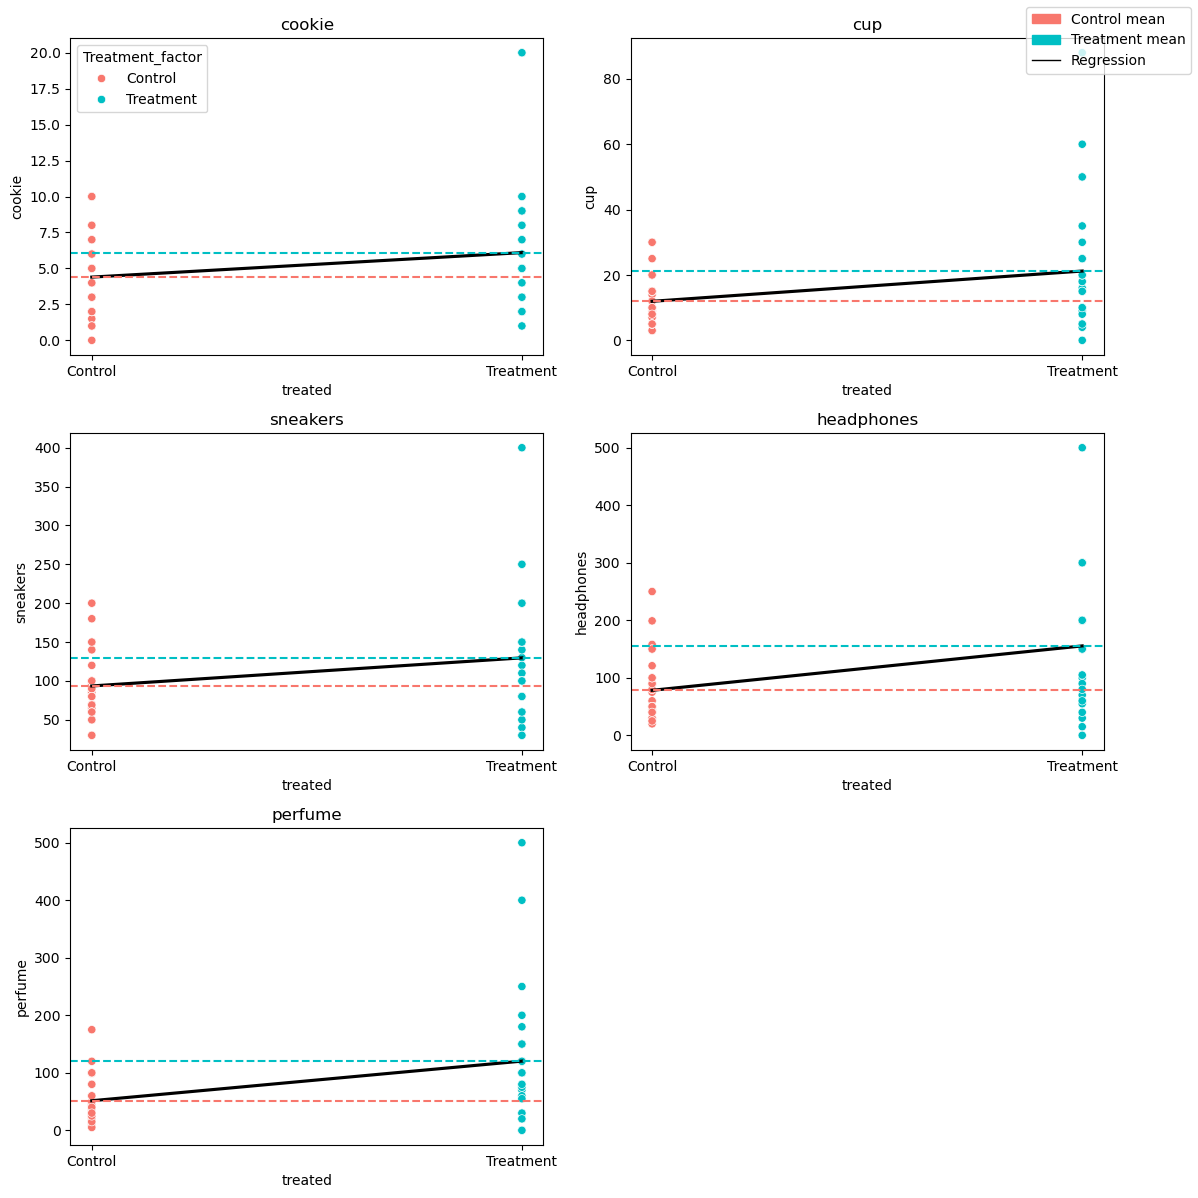

In [6]:
# Replace plotting cell with this code (plots one panel per column)
import math
import matplotlib.patches as mpatches

exp_cols = ['cookie','cup','sneakers','headphones','perfume']
cols_present = [c for c in exp_cols if c in df.columns]
if len(cols_present) == 0:
    raise RuntimeError("None of the expected experiment columns found in df.")

# ensure Treatment_factor exists
if 'Treatment_factor' not in df.columns:
    df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})

n = len(cols_present)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

custom_palette = {'Control': '#F8776D', 'Treatment': '#00BFC4'}

for i, col in enumerate(cols_present):
    ax = axes[i // ncols][i % ncols]
    # numeric series for plotting/stats
    series = pd.to_numeric(df[col], errors='coerce')

    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()

    # scatterplot (show legend only on first plot)
    show_legend = (i == 0)
    sns.scatterplot(data=df, x='treated', y=col, hue='Treatment_factor',
                    palette=custom_palette, ax=ax, legend=show_legend)

    # regression line
    sns.regplot(data=df, x='treated', y=col, scatter=False, color='black',
                label='Regression', ci=None, ax=ax)

    # mean lines
    ax.axhline(mean_ctr, linestyle='--', color=custom_palette['Control'], label='Mean Control' if show_legend else "")
    ax.axhline(mean_trt, linestyle='--', color=custom_palette['Treatment'], label='Mean Treatment' if show_legend else "")

    ax.set_title(col)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Treatment'])

# remove unused subplots
total_plots = nrows * ncols
for j in range(n, total_plots):
    ax = axes[j // ncols][j % ncols]
    ax.axis('off')

# if legend suppressed on other plots, create a single legend
handles = [
    mpatches.Patch(color=custom_palette['Control'], label='Control mean'),
    mpatches.Patch(color=custom_palette['Treatment'], label='Treatment mean'),
]
# add regression line handle
handles.append(plt.Line2D([0], [0], color='black', lw=1, label='Regression'))
fig.legend(handles=handles, loc='upper right')

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()



In [7]:
reg_results = {}
for col in exp_cols:
    lm = smf.ols(formula=f'{col} ~ treated', data=df)
    fit = lm.fit(cov_type='HC1')
    reg_results[col] = fit


In [8]:
reg_results['cookie'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 cookie   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     3.049
Date:                Thu, 26 Feb 2026   Prob (F-statistic):             0.0857
Time:                        10:19:39   Log-Likelihood:                -175.03
No. Observations:                  64   AIC:                             354.1
Df Residuals:                      62   BIC:                             358.4
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.3971      0.494      8.907      0.000       3.430       5.365
treated        1.7029      0.975      1.746      0.081      -0.208       3.614
==============================================================================
Omnibus:                       31.969   Durbin-Watson:                   2.359
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               66.397
Skew:                           1.663   Prob(JB):                     3.82e-15
Kurtosis:                       6.720   Cond. No.                         2.55
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [9]:

reg_results['cup'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cup   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     6.295
Date:                Thu, 26 Feb 2026   Prob (F-statistic):             0.0147
Time:                        10:19:39   Log-Likelihood:                -258.95
No. Observations:                  64   AIC:                             521.9
Df Residuals:                      62   BIC:                             526.2
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.9406      1.232      9.692      0.000       9.526      14.355
treated        9.2594      3.690      2.509      0.012       2.026      16.492
==============================================================================
Omnibus:                       49.200   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              202.257
Skew:                           2.238   Prob(JB):                     1.20e-44
Kurtosis:                      10.471   Cond. No.                         2.55
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

'sneakers','headphones','perfume'

In [10]:
reg_results['headphones'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             headphones   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     12.34
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           0.000832
Time:                        10:19:39   Log-Likelihood:                -373.61
No. Observations:                  64   AIC:                             751.2
Df Residuals:                      62   BIC:                             755.5
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     78.2644      8.928      8.766      0.000      60.766      95.763
treated       77.2023     21.974      3.513      0.000      34.135     120.270
==============================================================================
Omnibus:                       23.893   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               44.652
Skew:                           1.245   Prob(JB):                     2.01e-10
Kurtosis:                       6.248   Cond. No.                         2.55
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [11]:
reg_results['sneakers'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               sneakers   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     4.989
Date:                Thu, 26 Feb 2026   Prob (F-statistic):             0.0291
Time:                        10:19:39   Log-Likelihood:                -354.33
No. Observations:                  64   AIC:                             712.7
Df Residuals:                      62   BIC:                             717.0
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     93.5291      7.259     12.885      0.000      79.302     107.756
treated       36.1375     16.180      2.234      0.026       4.426      67.849
==============================================================================
Omnibus:                       31.430   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               74.053
Skew:                           1.539   Prob(JB):                     8.31e-17
Kurtosis:                       7.277   Cond. No.                         2.55
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [12]:
reg_results['perfume'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                perfume   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     11.13
Date:                Thu, 26 Feb 2026   Prob (F-statistic):            0.00144
Time:                        10:19:39   Log-Likelihood:                -369.00
No. Observations:                  64   AIC:                             742.0
Df Residuals:                      62   BIC:                             746.3
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     51.4706      6.366      8.085      0.000      38.993      63.948
treated       68.8627     20.644      3.336      0.001      28.401     109.325
==============================================================================
Omnibus:                       56.442   Durbin-Watson:                   2.378
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.321
Skew:                           2.509   Prob(JB):                     5.02e-67
Kurtosis:                      12.451   Cond. No.                         2.55
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

## Regression with multiple features    
i.e.   Age	Gender	shopping_freq	limi_prod_imp	

                            OLS Regression Results                            
Dep. Variable:                 cookie   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     1.768
Date:                Thu, 26 Feb 2026   Prob (F-statistic):              0.122
Time:                        10:19:39   Log-Likelihood:                -170.84
No. Observations:                  64   AIC:                             355.7
Df Residuals:                      57   BIC:                             370.8
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.0874      1.619      0.

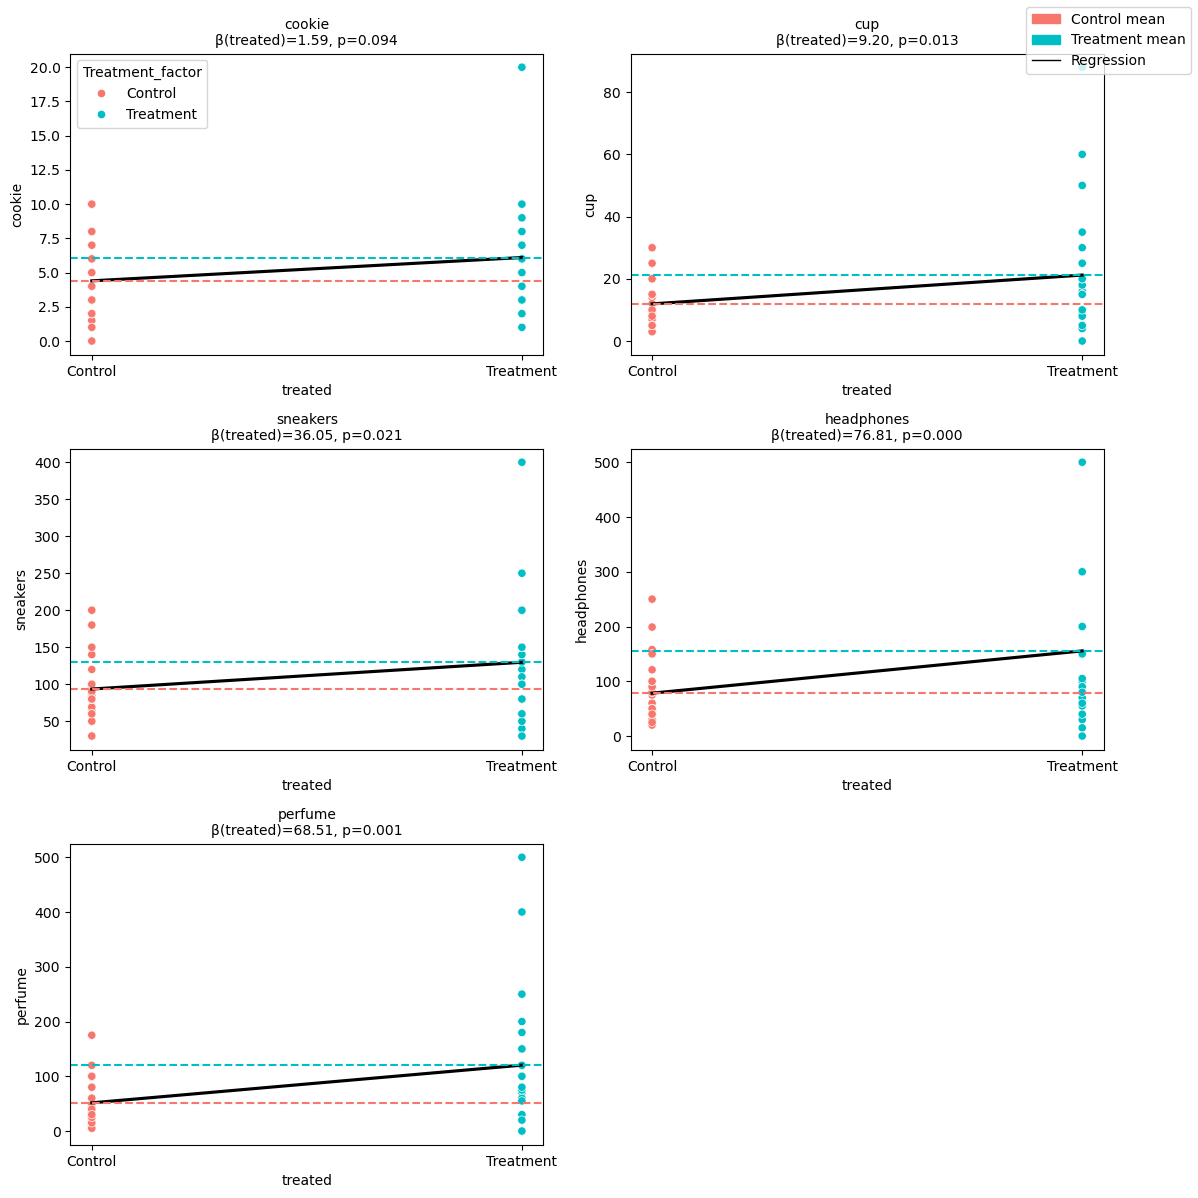

In [13]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').astype('category')
df['Gender'] = df['Gender'].astype('category')  # keeps Male/Female/Third gender/Prefer not to say as-is

if 'Treatment_factor' not in df.columns:
    df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})

# --- Regressions with covariates ---
reg_results = {}
covariate_formula = 'treated + C(Age) + C(Gender) + shopping_freq'  # <-- C(Gender) added

for col in cols_present:
    df_reg = df[[col, 'treated', 'Age', 'Gender', 'shopping_freq']].copy()
    for c in [col, 'treated', 'shopping_freq']:
        df_reg[c] = pd.to_numeric(df_reg[c], errors='coerce')
    df_reg['Age'] = df_reg['Age'].astype('category')
    df_reg['Gender'] = df_reg['Gender'].astype('category')
    df_reg = df_reg.dropna()

    lm = smf.ols(formula=f'{col} ~ {covariate_formula}', data=df_reg)
    fit = lm.fit(cov_type='HC1', use_t=False)
    reg_results[col] = fit

    try:
        print(fit.summary())
    except ValueError:
        print("Summary failed (F-stat issue with HC1), showing manual output:")
        print(fit.params.to_frame('coef')
                .join(fit.bse.to_frame('std_err'))
                .join(fit.tvalues.to_frame('t'))
                .join(fit.pvalues.to_frame('p-value'))
                .join(fit.conf_int().rename(columns={0: 'CI_low', 1: 'CI_high'}))
                .round(4))
        print(f"R²: {fit.rsquared:.4f} | Adj. R²: {fit.rsquared_adj:.4f} | AIC: {fit.aic:.2f} | BIC: {fit.bic:.2f}")

# --- Plots ---
n = len(cols_present)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

custom_palette = {'Control': '#F8776D', 'Treatment': '#00BFC4'}

for i, col in enumerate(cols_present):
    ax = axes[i // ncols][i % ncols]
    series = pd.to_numeric(df[col], errors='coerce')
    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()

    show_legend = (i == 0)
    sns.scatterplot(data=df, x='treated', y=col, hue='Treatment_factor',
                    palette=custom_palette, ax=ax, legend=show_legend)
    sns.regplot(data=df, x='treated', y=col, scatter=False, color='black',
                ci=None, ax=ax)
    ax.axhline(mean_ctr, linestyle='--', color=custom_palette['Control'])
    ax.axhline(mean_trt, linestyle='--', color=custom_palette['Treatment'])

    coef = reg_results[col].params['treated']
    pval = reg_results[col].pvalues['treated']
    ax.set_title(f"{col}\nβ(treated)={coef:.2f}, p={pval:.3f}", fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Treatment'])

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

handles = [
    mpatches.Patch(color=custom_palette['Control'], label='Control mean'),
    mpatches.Patch(color=custom_palette['Treatment'], label='Treatment mean'),
    plt.Line2D([0], [0], color='black', lw=1, label='Regression'),
]
fig.legend(handles=handles, loc='upper right')
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()